In [34]:
import math
import cmath
import graphviz
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from openpyxl import load_workbook
from array import array

import qiskit as q
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.visualization import *
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, Pauli, SparsePauliOp, Operator
from qiskit.transpiler import CouplingMap
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import *
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, SamplerV2 as Sampler
from qiskit.visualization import plot_bloch_vector
from qiskit.visualization.bloch import Bloch

In [35]:
# Save an IBM Quantum account and set it as your default account.
API_Token = '13d9540e280b61b7a4254fcdb05516180957df07523dfef1924f7d9363699a51826b42e7a063b3fb685f295f6d27f8ff61810a97f503a704c07bc959d6cc6e3f'
QiskitRuntimeService.save_account(
    channel = "ibm_quantum",
    
    instance = "ibm-q-hub-ntu/chen-hong-bin/default",
    token = API_Token,
    set_as_default = True,
    # Use `overwrite=True` if you're updating your token.
    overwrite = True,
)

# Load saved credentials
service = QiskitRuntimeService()

#For real Device
#backend = service.least_busy(operational=True, simulator=False)
backend_nazca = service.backend("ibm_kyiv")
noise_model = NoiseModel.from_backend(backend_nazca)

# Get basis gates from noise model
basis_gates = noise_model.basis_gates

#For FakeSimulator
#backend = FakeManilaV2()

# Get coupling map from backend
coupling_map = [[0, 1], [1, 2], [3, 2], [3, 4]]

#For Aer
backend = AerSimulator(noise_model=noise_model,
                       coupling_map=coupling_map,
                       basis_gates=basis_gates)
#backend = AerSimulator()
#backend = AerSimulator.from_backend(backend_nazca)

backendqubitNum = backend.num_qubits

In [62]:
#Cnot gate
qreg = QuantumRegister(2, 'q')
creg = ClassicalRegister(2, 'c')
Circuit = QuantumCircuit(qreg, creg)
Circuit.x(0)
Circuit.h(1)
Cnotgate = QuantumCircuit(qreg, creg)
Cnotgate.cx(0, 1)
Cnotgate.cx(0, 1)
Circuit = q.circuit.QuantumCircuit.compose(Circuit, Cnotgate)

Set = {"0":Circuit}
for i in range(100):
    Circuit = q.circuit.QuantumCircuit.compose(Circuit, Cnotgate)
    Memory = Circuit
    Set.update({f'{i+1}':Circuit})

In [63]:
for count, circuit in Set.items():   
    circuit.save_density_matrix()
    Set.update({count:circuit})

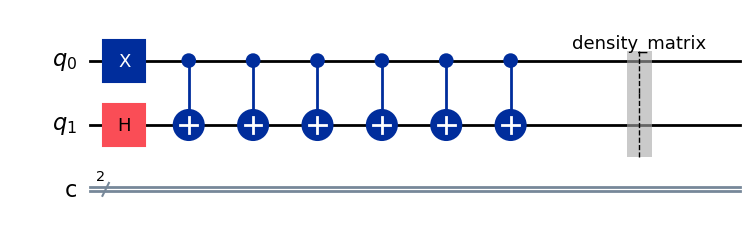

In [65]:
Set['2'].draw(output = 'mpl')

In [67]:
# 取得最終狀態並做部分蹤跡
reduced_state = {}

# 使用 density_matrix 儲存狀態
for count, circuit in Set.items():    
    qc = transpile(circuit, backend)
    result = backend.run(qc).result()
    
    # Get Density Matrix
    final_state = DensityMatrix(result.data()["density_matrix"])
    
    # Get q1 Densuty Matrix（trace out q0）
    reduced_state.update({count:partial_trace(final_state, [0])})  # 丟棄 qubit 0，留下 qubit 1

In [68]:
reduced_state

{'0': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
                [0.49976353+0.j, 0.4999464 +0.j]],
               dims=(2,)),
 '1': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
                [0.49976353+0.j, 0.4999464 +0.j]],
               dims=(2,)),
 '2': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
                [0.49976353+0.j, 0.4999464 +0.j]],
               dims=(2,)),
 '3': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
                [0.49976353+0.j, 0.4999464 +0.j]],
               dims=(2,)),
 '4': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
                [0.49976353+0.j, 0.4999464 +0.j]],
               dims=(2,)),
 '5': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
                [0.49976353+0.j, 0.4999464 +0.j]],
               dims=(2,)),
 '6': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
                [0.49976353+0.j, 0.4999464 +0.j]],
               dims=(2,)),
 '7': DensityMatrix([[0.5000536 +0.j, 0.49976353+0.j],
              

In [69]:
# 初始化 Bloch 球
bloch_sphere = Bloch()

# 直接計算布洛赫球座標
for count, state in reduced_state.items():
    rho = DensityMatrix(state)
    bloch_vector = [
        rho.expectation_value(DensityMatrix([[0, 1], [1, 0]])).real,  # X
        rho.expectation_value(DensityMatrix([[0, -1j], [1j, 0]])).real,  # Y
        rho.expectation_value(DensityMatrix([[1, 0], [0, -1]])).real  # Z
    ]
    
    # 在 Bloch 球上標記點
    bloch_sphere.add_vectors(bloch_vector)

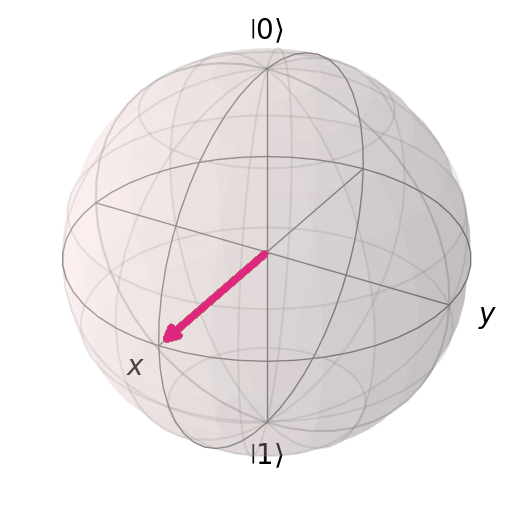

In [70]:
# 繪製 Bloch 球
bloch_sphere.render()
plt.show()